In [3]:
import pandas as pd
df = pd.read_csv("loan_prediction.csv")
print(df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [5]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])


In [6]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())


In [8]:
df = df.drop('Loan_ID', axis=1)


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])   # target


In [10]:
if 'Dependents' in df.columns or 'Property_Area' in df.columns:
    df = pd.get_dummies(
        df,
        columns=['Dependents', 'Property_Area'],
        drop_first=True
    )




In [11]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Education                614 non-null    int64  
 3   Self_Employed            614 non-null    int64  
 4   ApplicantIncome          614 non-null    int64  
 5   CoapplicantIncome        614 non-null    float64
 6   LoanAmount               614 non-null    float64
 7   Loan_Amount_Term         614 non-null    float64
 8   Credit_History           614 non-null    float64
 9   Loan_Status              614 non-null    int64  
 10  Dependents_1             614 non-null    bool   
 11  Dependents_2             614 non-null    bool   
 12  Dependents_3+            614 non-null    bool   
 13  Property_Area_Semiurban  614 non-null    bool   
 14  Property_Area_Urban      6

In [12]:
# Separate features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% for testing
    random_state=42  # reproducible results
)


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest with 3 trees
rf = RandomForestClassifier(
    n_estimators=3,       # number of trees
    criterion='entropy',  # use information gain
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)


RandomForestClassifier(criterion='entropy', n_estimators=3, random_state=42)

In [33]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7073170731707317
              precision    recall  f1-score   support

           0       0.60      0.49      0.54        43
           1       0.75      0.82      0.79        80

    accuracy                           0.71       123
   macro avg       0.68      0.66      0.66       123
weighted avg       0.70      0.71      0.70       123



In [34]:
# Hardcoded new applicant
new_sample = pd.DataFrame([{
    'Gender': 1,                # Male
    'Married': 1,               # Yes
    'Education': 1,             # Graduate
    'Self_Employed': 0,         # No
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Dependents_1': 0,
    'Dependents_2': 1,
    'Dependents_3+': 0,
    'Property_Area_Semiurban': 1,
    'Property_Area_Urban': 0
}])

# Align columns to match training data
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)
# Predict loan status
prediction = rf.predict(new_sample)

# Print result
print("Loan Status Prediction:", "Approved" if prediction[0] == 1 else "Rejected")

Loan Status Prediction: Approved


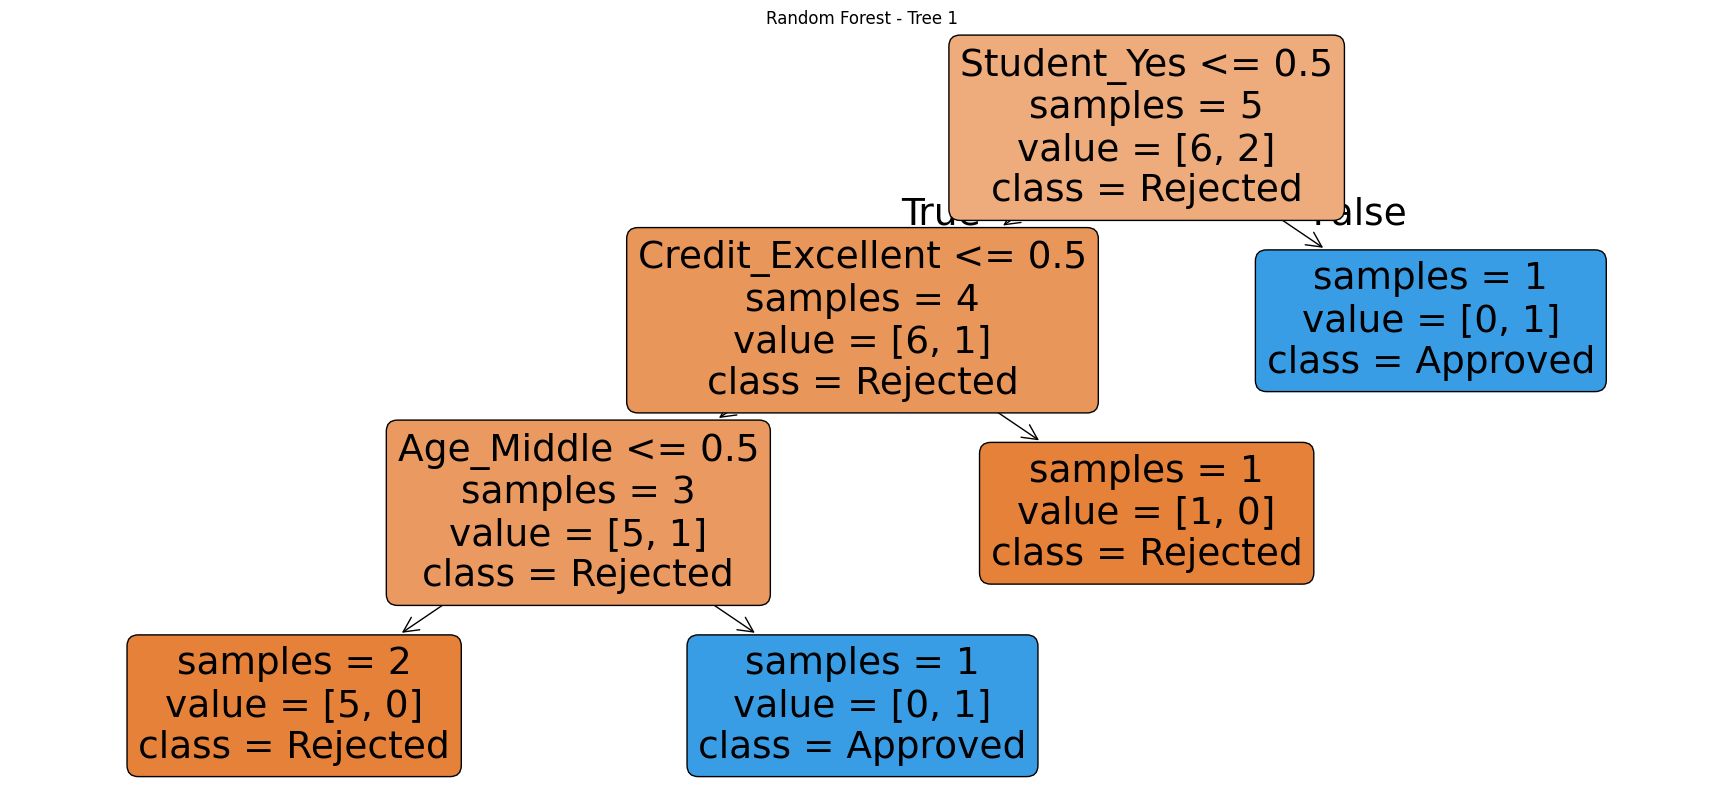

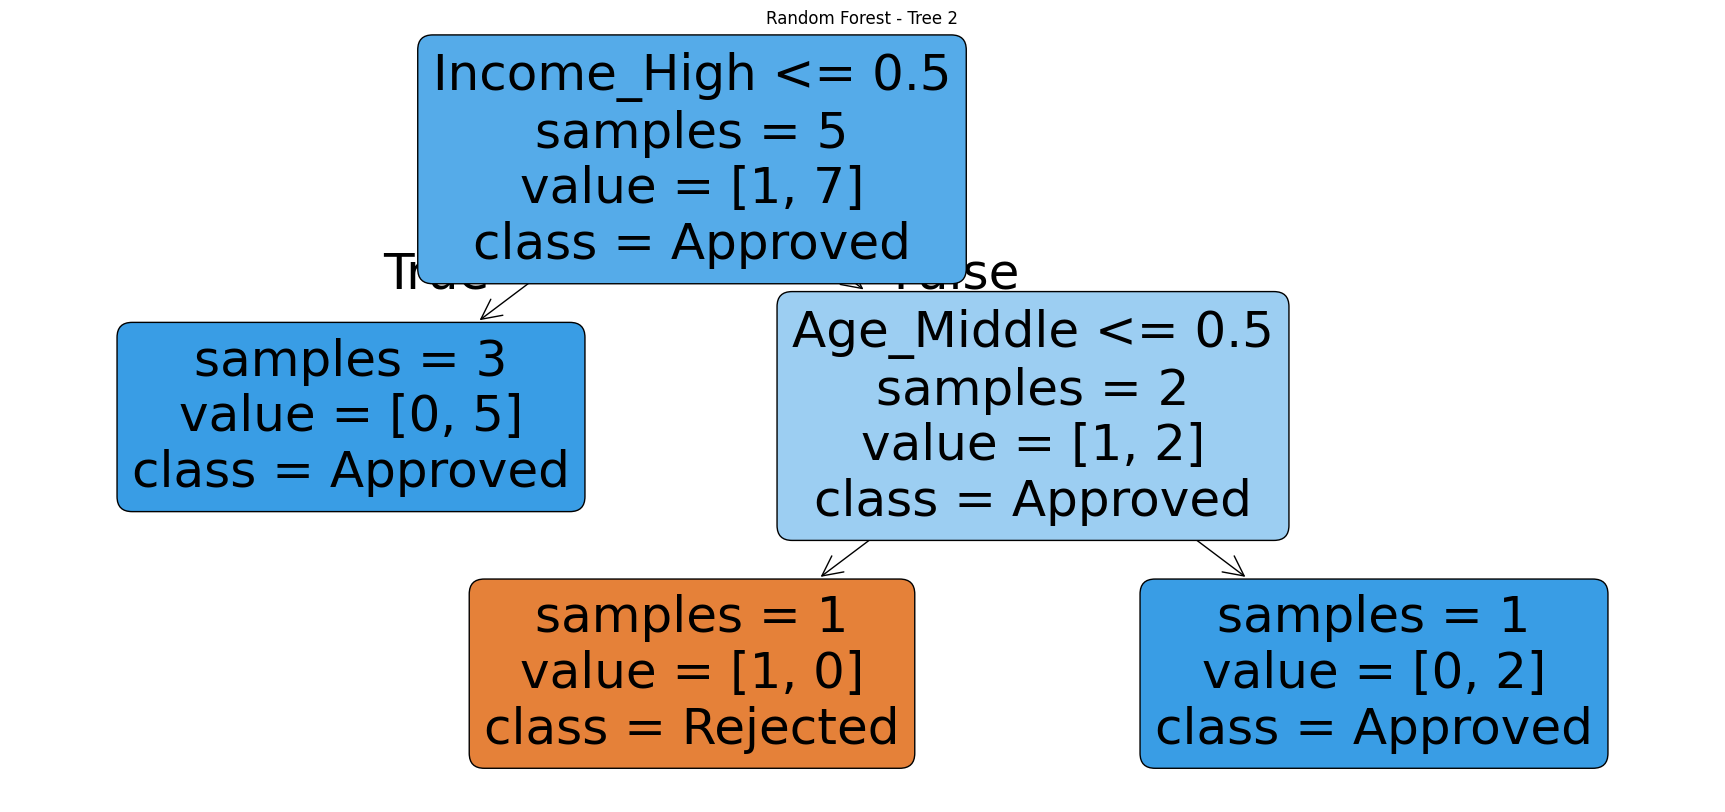

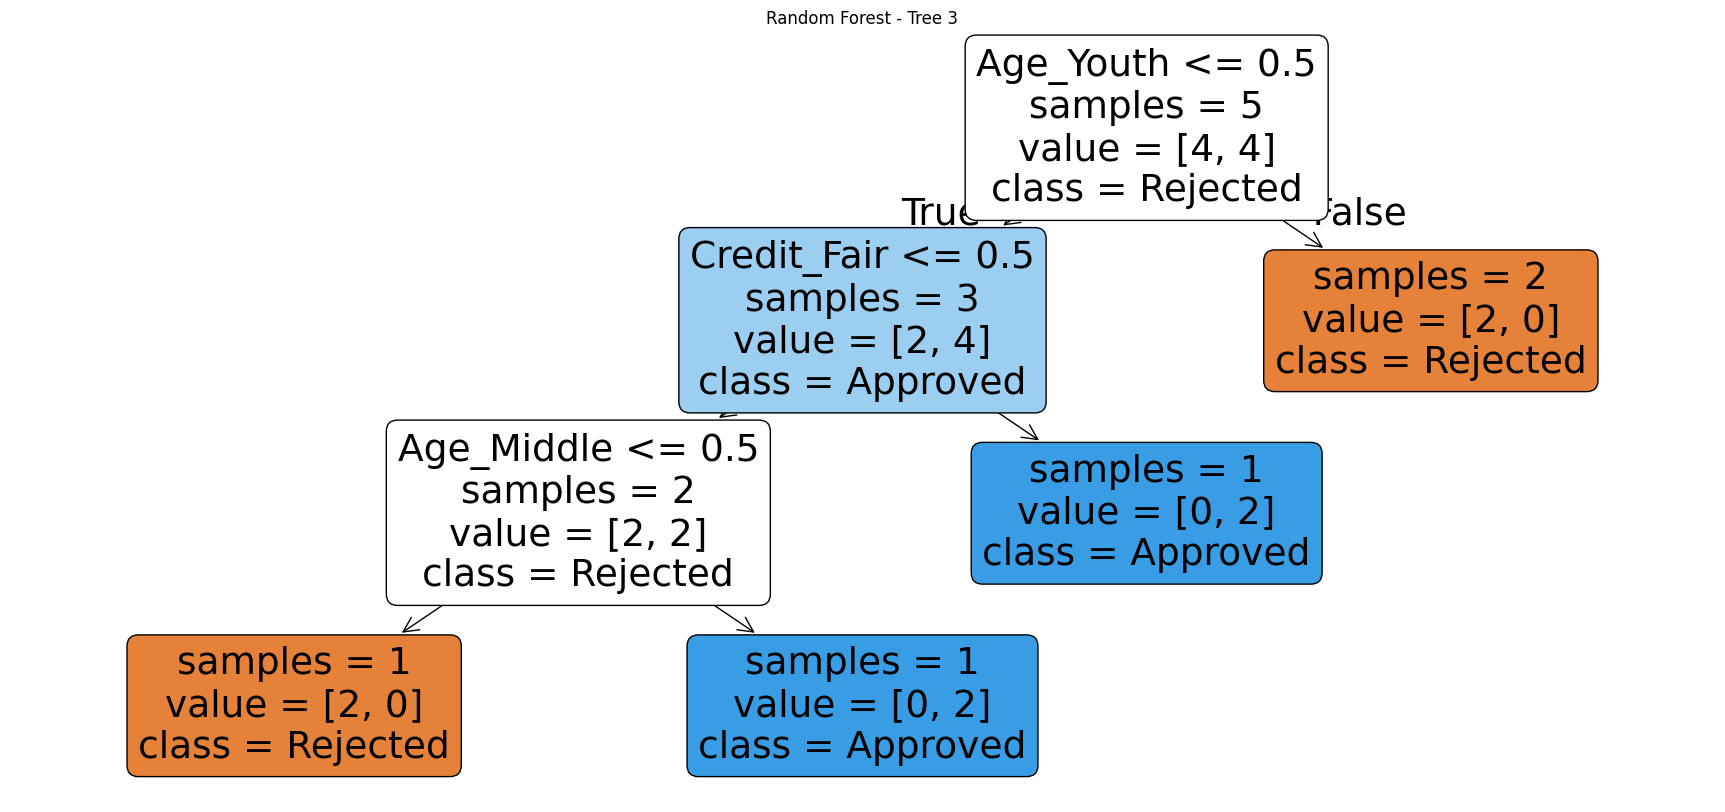

In [27]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

for i, tree in enumerate(rf.estimators_):
    plt.figure(figsize=(22, 10))
    plot_tree(
        tree,
        feature_names=X.columns,
        class_names=['Rejected', 'Approved'],
        filled=True,
        rounded=True,
        impurity=False  # hides entropy
    )
    plt.title(f"Random Forest - Tree {i+1}")
    plt.show()


In [14]:

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# -------------------------------
rf = RandomForestClassifier(n_estimators=3, criterion='entropy', random_state=42)
rf.fit(X_train, y_train)

# -------------------------------
# Step 6: Hardcoded new sample
# -------------------------------
new_sample = pd.DataFrame([{
    'Gender': 1,
    'Married': 1,
    'Education': 1,
    'Self_Employed': 0,
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Dependents_1': 0,
    'Dependents_2': 1,
    'Dependents_3+': 0,
    'Property_Area_Semiurban': 1,
    'Property_Area_Urban': 0
}])

# Align columns with training data
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = rf.predict(new_sample)
print("Loan Status Prediction:", "Approved" if prediction[0]==1 else "Rejected")


Loan Status Prediction: Approved
